## Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксация генератора случайных чисел для воспроизводимости результатов
np.random.seed(42)

## Методы

In [2]:
def calculate_rmse(true, estimated):
    """Расчёт среднеквадратичной ошибки (RMSE)."""
    return np.sqrt(np.mean((np.array(true) - np.array(estimated))**2))

def plot_time_series(time, true, measured, filtered, ylabel, title, cov_history=None):
    """Построение графика временного ряда."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(time, true, 'k-', label='Истинное значение', linewidth=2)
    ax.plot(time, measured, 'b.', label='Измерение (с шумом)', alpha=0.5)
    ax.plot(time, filtered, 'r-', label='Оценка фильтра', linewidth=2)
    
    if cov_history is not None:
        plot_time = time[:len(cov_history)]
        ax2 = ax.twinx()
        ax2.plot(plot_time, cov_history, 'g--', label='Ковариация (P)', alpha=0.6)
        ax2.set_ylabel('Ковариация ошибки (P)', color='green')
        ax2.set_ylim(0, max(cov_history) * 1.2)
        
    ax.set_xlabel('Время (шаг)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_trajectory_2d(true_x, true_y, meas_x, meas_y, est_x, est_y, title):
    """Построение 2D траектории в пространстве X-Y."""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(true_x, true_y, 'k-', label='Истинная траектория', lw=2)
    ax.plot(meas_x, meas_y, 'b.', label='Измерения (Датчик)', alpha=0.4)
    ax.plot(est_x, est_y, 'r-', label='Оценка фильтра', lw=2)
    
    ax.set_xlabel('X (м)')
    ax.set_ylabel('Y (м)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

## Задание 1


 ЗАДАНИЕ 1: Скалярный фильтр Калмана (1D) – Статический объект
RMSE (Задача 1): 0.417


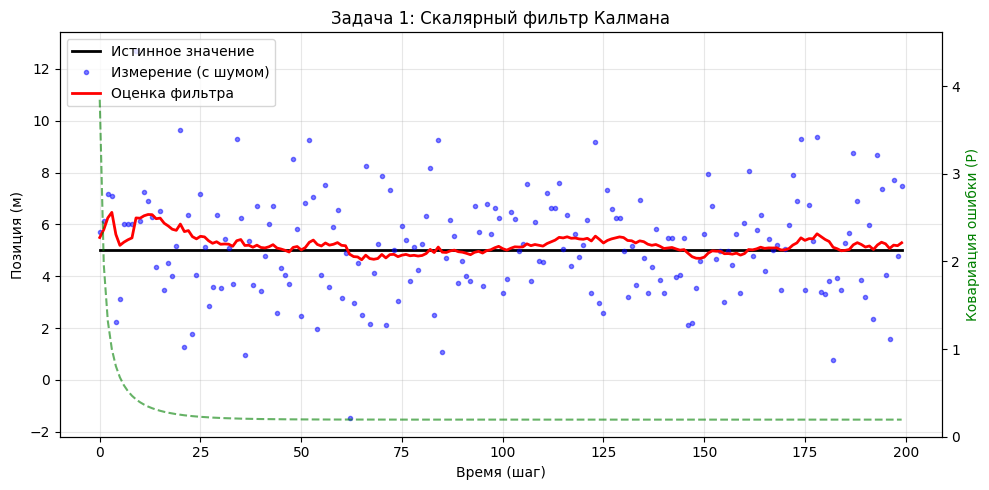


ВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 1):
1. Почему ковариация P монотонно убывает на начальных шагах?
2. Как изменится график оценки, если Q >> R?
3. Что произойдёт, если R << Q?


In [ ]:
# ======================== ЗАДАНИЕ 1 ========================
print("\n ЗАДАНИЕ 1: Скалярный фильтр Калмана (1D) – Статический объект")
# --- 1. Симуляция данных ---
dt_1 = 0.05  # Шаг дискретизации времени (секунды между измерениями)               
N_1 = 200    # Общее количество шагов симуляции               
true_pos_1 = 5.0 * np.ones(N_1) # Массив истинной позиции (объект неподвижен на отметке 5.0 м) 
noise_sigma_1 = 2.0     # Стандартное отклонение (СКО) шума датчика      
measurements_1 = true_pos_1 + np.random.normal(0, noise_sigma_1, N_1) # Зашумленные измерения (истина + гауссов шум)
time_1 = np.arange(N_1)     # Временная шкала (индексы шагов 0..199 для оси X графиков)

class KF1D:
    """Одномерный фильтр Калмана для статического объекта"""
    def __init__(self, q, r):
        self.Q = q          # Q: Дисперсия шума процесса (неопределённость динамической модели)
        self.R = r          # R: Дисперсия шума измерения (неточность/шум датчика)
        self.x = 0.0        # Текущая оценка состояния (позиция объекта)
        self.P = 100.0      # P: Ковариация ошибки оценки (начальная неуверенность фильтра)
        self.F = 1.0        # F: Матрица перехода состояния (для статики x_k = 1 * x_{k-1})
        self.H = 1.0        # H: Матрица наблюдения (связь состояния с измерением, здесь прямая)
        self.P_history = [] # Список для сохранения истории ковариации P (для анализа сходимости)

    def predict(self):
        # TODO: реализуйте этап предсказания
        # x_pred = F * x
        # P_pred = F * P * F + Q
        self.x_pred = self.F * self.x
        self.P_pred = self.F * self.P * self.F + self.Q # Неуверенность фильтра в своей оценке

    def update(self, z):
        # TODO: реализуйте этап коррекции
        # y (невязка) = z - H * x_pred
        # S = H * P_pred * H + R
        # K = P_pred * H / S
        # x = x_pred + K * y
        # P = (1 - K * H) * P_pred
        # self.P_history.append(P)
        y = z - self.H * self.x_pred # На сколько измерение отличается от предсказания
        S = self.H * self.P_pred * self.H + self.R
        K = (self.P_pred * self.H) / S #Насколько я доверяю измерению vs своей модели?

        #Если P_pred большое (фильтр сильно не уверен) → K близко к 1 → сильно верим измерению
        #Если P_pred маленькое (фильтр уже уверен) → K близко к 0 → почти игнорируем измерение
        
        self.x = self.x_pred + K * y    # корректируем оценку
        self.P = (1 - K * self.H) * self.P_pred          # теперь self.P = P_{k|k} уменьшаем свою неуверенность
        
        self.P_history.append(self.P)

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ:
Q_student_1 = 0.01   # TODO: подберите дисперсию шума процесса
R_student_1 = 4.0   # TODO: подберите дисперсию шума измерения

kf_1 = KF1D(q=Q_student_1, r=R_student_1)
filtered_1 = [] 

for z in measurements_1:
    # TODO: вызовите kf_1.predict()
    # TODO: вызовите kf_1.update(z)
    # TODO: сохраните kf_1.x в filtered_1
    kf_1.predict()
    kf_1.update(z)
    filtered_1.append(kf_1.x)

# --- 3. Визуализация и метрики ---
rmse_1 = calculate_rmse(true_pos_1, filtered_1)
print(f"RMSE (Задача 1): {rmse_1:.3f}")
plot_time_series(time_1, true_pos_1, measurements_1, filtered_1,
                 "Позиция (м)", "Задача 1: Скалярный фильтр Калмана", kf_1.P_history)

print("\nВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 1):")
print("1. Почему ковариация P монотонно убывает на начальных шагах?")
print("2. Как изменится график оценки, если Q >> R?")
print("3. Что произойдёт, если R << Q?")

1. Почему ковариация P монотонно убывает на начальных шагах?

Потому что начальная неуверенность (P=100) очень высокая. На каждом шаге фильтр получает информацию от измерений и постепенно "убеждается" в своей оценке. Формула обновления P = (1-K)*P_pred при большом K даёт сильное уменьшение P.

2. Как изменится график оценки, если Q >> R?

Фильтр будет сильно доверять измерениям и слабо — своей модели.
Оценка (красная линия) будет очень близко следовать зашумлённым синим точкам. Фильтрация будет слабой.

3. Что произойдёт, если R << Q?

Фильтр будет сильно доверять модели ("объект стоит") и почти игнорировать измерения.
Красная линия будет почти прямой (близко к 5.0), даже если измерения сильно скачут. Фильтрация будет очень сильной (может быть даже слишком сильной).

## Задание 2


ЗАДАНИЕ 2: Фильтр постоянной скорости (1D) – Скрытые состояния
Цель: Оценить скорость, имея только зашумлённые измерения координаты.
RMSE позиции (Задача 2): 0.632


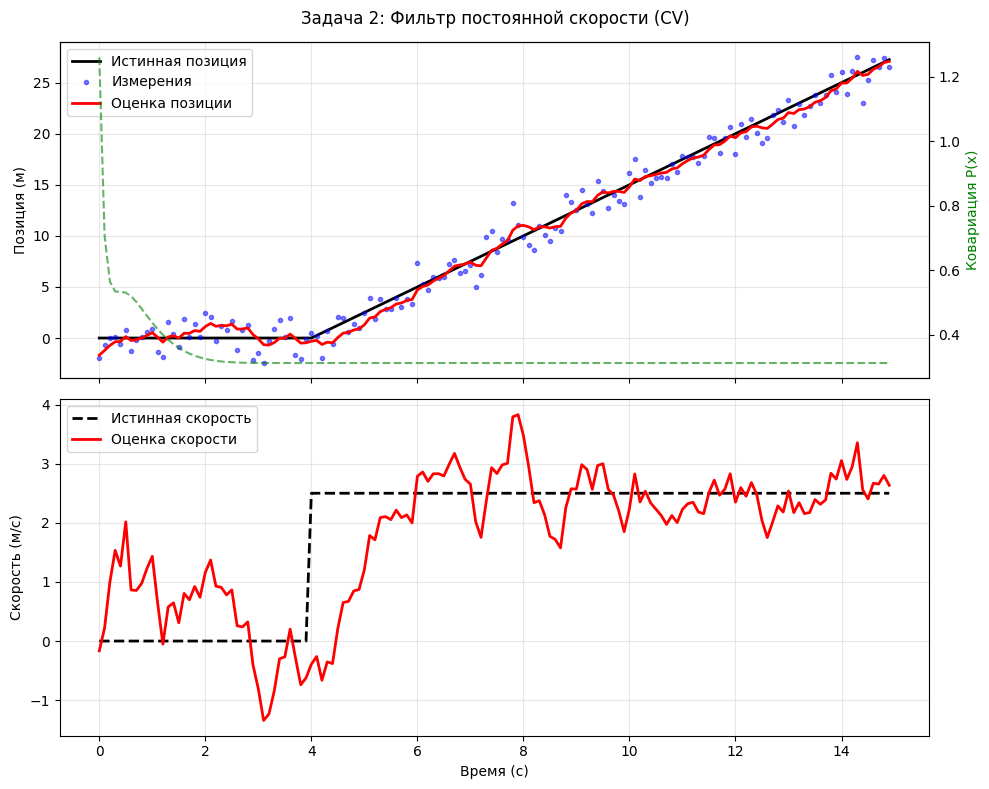


 ВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 2):
1. Каким образом фильтр оценивает скорость без прямого измерения?
2. Как быстро фильтр реагирует на скачок скорости на 4-й секунде?
3. Как увеличение q_vel влияет на динамику отклика?


In [6]:
# ======================== ЗАДАНИЕ 2 ========================
print("\nЗАДАНИЕ 2: Фильтр постоянной скорости (1D) – Скрытые состояния")
print("Цель: Оценить скорость, имея только зашумлённые измерения координаты.")

# --- 1. Симуляция данных ---
dt_2 = 0.1    # Шаг времени (секунды)            
N_2 = 150     # Количество шагов симуляции          
time_2 = np.arange(N_2) * dt_2 # Временная шкала в секундах для оси X

true_pos_2 = np.zeros(N_2)   # Массив истинной позиции (начально 0)
true_vel_2 = np.zeros(N_2)   # Массив истинной скорости (начально 0)
true_vel_2[40:] = 2.5        # С 40-го шага объект движется с постоянной скоростью 2.5 м/с

# Интегрирование скорости для получения истинной позиции по времени
for i in range(1, N_2):
    true_pos_2[i] = true_pos_2[i-1] + true_vel_2[i-1] * dt_2

noise_sigma_2 = 1.2  # СКО шума датчика координаты         
measurements_2 = true_pos_2 + np.random.normal(0, noise_sigma_2, N_2) # Зашумленные измерения позиции

class KF_CV1D:
    """Фильтр Калмана для 1D движения с постоянной скоростью"""
    def __init__(self, dt, q_pos, q_vel, r_pos):
        # TODO: проверьте ниже правильно ли заданны матрицы
        # self.dt = dt
        # self.F = np.array([[1, dt], [0, 1]])
        # self.H = np.array([[1, 0]])
        # self.Q = np.diag([q_pos, q_vel])
        # self.R = np.array([[r_pos]])
        
        # self.x = np.array([[0.0], [0.0]]) 
        # self.P = np.eye(2) * 10.0         
        # self.P_pos_history = []
        self.dt = dt
        self.F = np.array([[1, dt], [0, 1]])
        self.H = np.array([[1, 0]])
        self.Q = np.diag([q_pos, q_vel])
        self.R = np.array([[r_pos]])
        
        self.x = np.array([[0.0], [0.0]])
        self.P = np.eye(2) * 10.0
        self.P_pos_history = []           

    def predict(self):
        # TODO: реализуйте матричное предсказание
        # x = F @ x
        # P = F @ P @ F.T + Q
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        # TODO: реализуйте матричную коррекцию
        # y = z - H @ x
        # S = H @ P @ H.T + R
        # K = P @ H.T / S[0,0]  (для скалярного случая измерения)
        # x = x + K @ y
        # P = (I - K @ H) @ P
        # self.P_pos_history.append(P[0,0])
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = (self.P @ self.H.T) / S[0,0]
        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ self.H) @ self.P
        self.P_pos_history.append(self.P[0,0])

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ:
q_pos_2 = 0.01      # Шум процесса по позиции (доверие к модели положения)
q_vel_2 = 0.1      # Шум процесса по скорости (доверие к модели постоянства скорости)
r_pos_2 = 1.44       # Шум измерения позиции (точность датчика)     

kf_2 = KF_CV1D(dt=dt_2, q_pos=q_pos_2, q_vel=q_vel_2, r_pos=r_pos_2)

filtered_pos_2 = [] # Список оцененных позиций
filtered_vel_2 = [] # Список оцененных скоростей

for z in measurements_2:
    # TODO: вызовите predict() и update(np.array([[z]]))
    # TODO: сохраните оценённые x[0,0] и x[1,0]
    kf_2.predict()
    kf_2.update(np.array([[z]]))
    filtered_pos_2.append(kf_2.x[0,0])
    filtered_vel_2.append(kf_2.x[1,0])

# --- 3. Визуализация и метрики ---
rmse_2 = calculate_rmse(true_pos_2, filtered_pos_2)
print(f"RMSE позиции (Задача 2): {rmse_2:.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(time_2, true_pos_2, 'k-', label='Истинная позиция', lw=2)
ax1.plot(time_2, measurements_2, 'b.', label='Измерения', alpha=0.5)
ax1.plot(time_2, filtered_pos_2, 'r-', label='Оценка позиции', lw=2)
ax1_twin = ax1.twinx()
ax1_twin.plot(time_2, kf_2.P_pos_history, 'g--', label='Ковариация P(x)', alpha=0.6)
ax1_twin.set_ylabel('Ковариация P(x)', color='green')
ax1.set_ylabel('Позиция (м)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(time_2, true_vel_2, 'k--', label='Истинная скорость', lw=2)
ax2.plot(time_2, filtered_vel_2, 'r-', label='Оценка скорости', lw=2)
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Скорость (м/с)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.suptitle("Задача 2: Фильтр постоянной скорости (CV)")
plt.tight_layout()
plt.show()

print("\n ВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 2):")
print("1. Каким образом фильтр оценивает скорость без прямого измерения?")
print("2. Как быстро фильтр реагирует на скачок скорости на 4-й секунде?")
print("3. Как увеличение q_vel влияет на динамику отклика?")


## Задание 3


 ЗАДАНИЕ 3: 2D фильтр Калмана (Блочная структура)
Цель: Реализовать многомерную фильтрацию с блочными матрицами.
RMSE X: 0.674 | Y: 0.729 | Total: 0.702


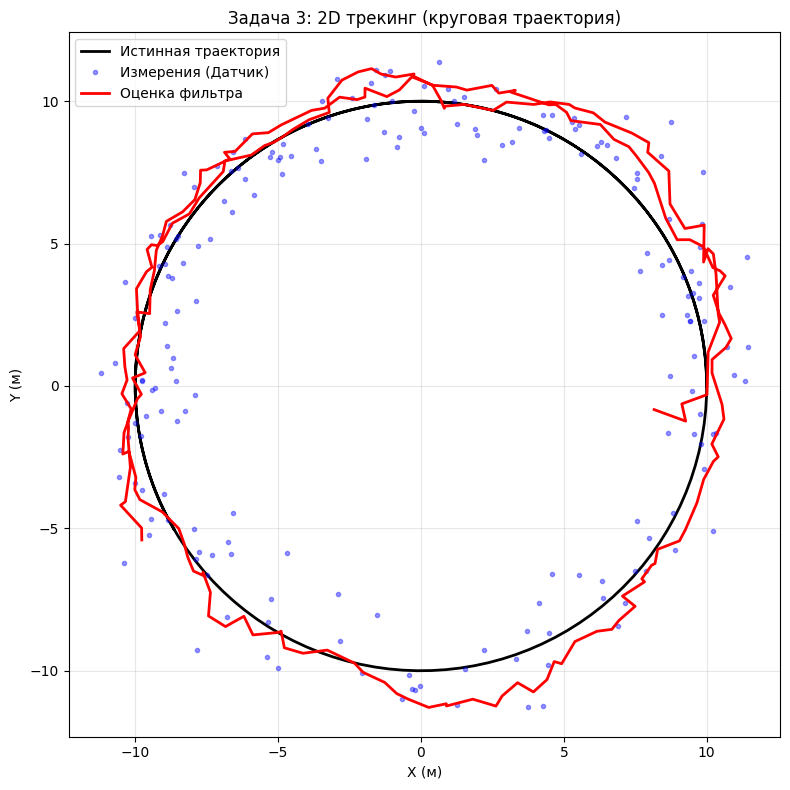


ВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 3):
1. Почему матрица F блочно-диагональная? Что это означает физически?
2. Как изменится траектория, если задать разные значения шума Q для X и Y?


In [8]:
# ======================== ЗАДАНИЕ 3 ========================
print("\n ЗАДАНИЕ 3: 2D фильтр Калмана (Блочная структура)")
print("Цель: Реализовать многомерную фильтрацию с блочными матрицами.")

# --- 1. Симуляция данных ---
dt_3 = 0.1
N_3 = 200
t_3 = np.arange(N_3)

omega_3 = 0.05            # Угловая скорость вращения (рад/шаг)
true_x_3 = 10 * np.cos(omega_3 * t_3) # Истинная координата X (круг радиусом 10)
true_y_3 = 10 * np.sin(omega_3 * t_3) # Истинная координата Y

noise_sigma_3 = 1.0       # СКО шума датчика
meas_x_3 = true_x_3 + np.random.normal(0, noise_sigma_3, N_3) # Зашумленное измерение X
meas_y_3 = true_y_3 + np.random.normal(0, noise_sigma_3, N_3) # Зашумленное измерение Y

# --- 2. Каркас фильтра ---
class KF_2D_CV:
    """2D Фильтр Калмана (состояние: x, vx, y, vy)."""
    def __init__(self, dt, q, r):
        self.dt = dt
        F_block = np.array([[1, dt], [0, 1]])
        self.F = np.block([[F_block, np.zeros((2,2))],
                           [np.zeros((2,2)), F_block]])
        self.H = np.array([[1, 0, 0, 0],
                           [0, 0, 1, 0]])
        self.Q = np.eye(4) * q
        self.R = np.eye(2) * r
        self.x = np.zeros((4,1))
        self.P = np.eye(4) * 5.0

    def predict(self):
        # TODO: x = F @ x; P = F @ P @ F.T + Q
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        # TODO: стандартная коррекция для многомерного случая
        # y = z - H @ x
        # S = H @ P @ H.T + R
        # K = P @ H.T @ np.linalg.inv(S)
        # x = x + K @ y
        # P = (I - K @ H) @ P
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ:
q_3 = 0.05      # Шум процесса (неопределённость движения)
r_3 = 1.0       # Шум измерения (точность датчика)      

kf_3 = KF_2D_CV(dt=dt_3, q=q_3, r=r_3)

est_x_3, est_y_3 = [], [] # Списки для сохранения отфильтрованных координат
for mx, my in zip(meas_x_3, meas_y_3):
    z_vec = np.array([[mx], [my]])
    # TODO: вызовите predict() и update(z_vec)
    # TODO: сохраните x[0,0] и x[2,0]
    kf_3.predict()
    kf_3.update(z_vec)
    est_x_3.append(kf_3.x[0,0])
    est_y_3.append(kf_3.x[2,0])

# --- 3. Визуализация и метрики ---
rmse_x3 = calculate_rmse(true_x_3, est_x_3)
rmse_y3 = calculate_rmse(true_y_3, est_y_3)
rmse_total3 = np.sqrt((rmse_x3**2 + rmse_y3**2) / 2)
print(f"RMSE X: {rmse_x3:.3f} | Y: {rmse_y3:.3f} | Total: {rmse_total3:.3f}")

plot_trajectory_2d(true_x_3, true_y_3, meas_x_3, meas_y_3, est_x_3, est_y_3, 
                   "Задача 3: 2D трекинг (круговая траектория)")

print("\nВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 3):")
print("1. Почему матрица F блочно-диагональная? Что это означает физически?")
print("2. Как изменится траектория, если задать разные значения шума Q для X и Y?")


## Задание 4


ЗАДАНИЕ 4: Расширенный фильтр Калмана (EKF) – Автомобиль
Цель: Реализовать линеаризацию нелинейной кинематической модели.
RMSE X: 0.244 | Y: 0.220 | Total: 0.232


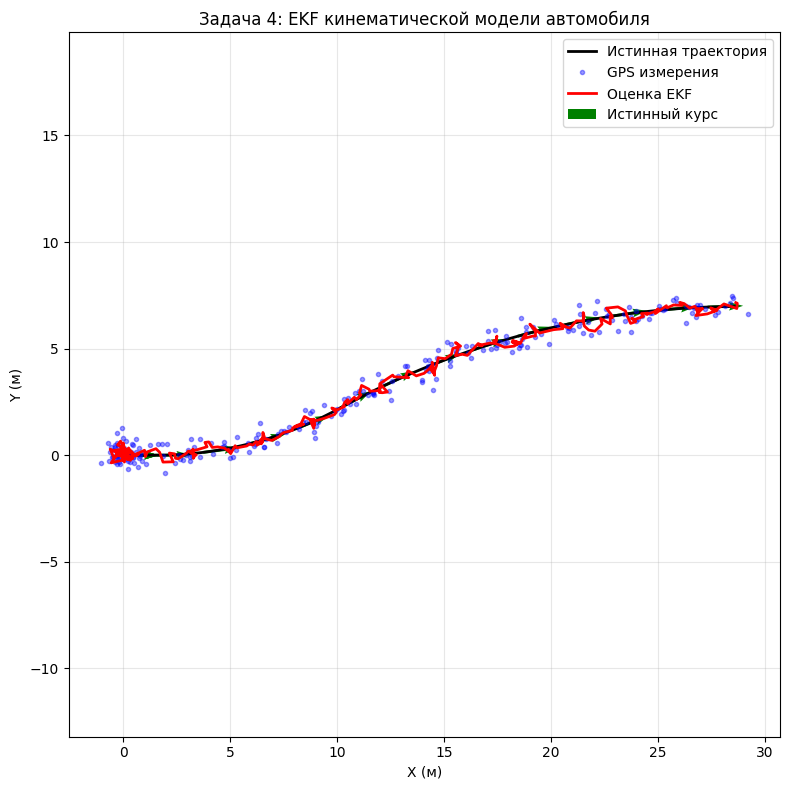


 ВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 4):
1. В чём ключевое отличие predict() в EKF от линейного KF?
2. Зачем необходима нормализация угла курса и как скачки ±π влияют на матрицу Якоби?
3. Как параметр Q компенсирует расхождение модели при резких поворотах?


In [9]:
# ======================== ЗАДАНИЕ 4 ========================
print("\nЗАДАНИЕ 4: Расширенный фильтр Калмана (EKF) – Автомобиль")
print("Цель: Реализовать линеаризацию нелинейной кинематической модели.")

# --- 1. Симуляция данных ---
dt_4 = 0.1
N_4 = 250
t_4 = np.arange(N_4)

# Инициализация массивов для истинной траектории
true_x_4, true_y_4, true_psi_4, true_v_4 = np.zeros(N_4), np.zeros(N_4), np.zeros(N_4), np.zeros(N_4)
true_v_4[50:] = 1.5  # Разгон до 1.5 м/с после 50-го шага

# Профиль изменения угла курса (рыскания) во времени
psi_profile_4 = np.zeros(N_4)
psi_profile_4[60:120] = np.linspace(0, 0.5, 60)   # Плавный поворот влево
psi_profile_4[120:] = np.linspace(0.5, 0, N_4-120) # Возврат к прямому движению

# Интегрирование нелинейной кинематической модели
for i in range(1, N_4):
    true_psi_4[i] = psi_profile_4[i]
    true_x_4[i] = true_x_4[i-1] + true_v_4[i-1] * np.cos(true_psi_4[i-1]) * dt_4
    true_y_4[i] = true_y_4[i-1] + true_v_4[i-1] * np.sin(true_psi_4[i-1]) * dt_4

noise_sigma_4 = 0.4
meas_x_4 = true_x_4 + np.random.normal(0, noise_sigma_4, N_4) # Зашумленные GPS-координаты X
meas_y_4 = true_y_4 + np.random.normal(0, noise_sigma_4, N_4) # Зашумленные GPS-координаты Y

# --- 2. Каркас EKF ---
class EKF_Car:
    """Extended Kalman Filter для кинематической модели автомобиля"""
    def __init__(self, dt, q, r):
        self.dt = dt
        self.x = np.array([[0.0], [0.0], [0.0], [0.5]]) # [x, y, psi, v]
        self.P = np.eye(4) * 5.0
        self.Q = np.eye(4) * q
        self.R = np.eye(2) * r
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]])

    def predict(self):
        x, y, psi, v = self.x[0,0], self.x[1,0], self.x[2,0], self.x[3,0]
        
        # TODO 1: Нелинейное предсказание состояния
        # x[0] = x + v*cos(psi)*dt
        # x[1] = y + v*sin(psi)*dt
        # x[2] = нормализуйте угол в [-pi, pi]
        # x[3] = v

        self.x[0,0] = x + v * np.cos(psi) * self.dt
        self.x[1,0] = y + v * np.sin(psi) * self.dt
        self.x[2,0] = psi  # угол не меняется в predict (управление отдельно)
        self.x[3,0] = v

        self.x[2,0] = (self.x[2,0] + np.pi) % (2 * np.pi) - np.pi
        
        # TODO 2: Вычислите матрицу Якоби F_jac = df/dx в точке прогноза
        # F_jac[0,2] = -v*sin(psi)*dt
        # F_jac[0,3] =  cos(psi)*dt
        # F_jac[1,2] =  v*cos(psi)*dt
        # F_jac[1,3] =  sin(psi)*dt

        F_jac = np.eye(4)
        F_jac[0,2] = -v * np.sin(psi) * self.dt
        F_jac[0,3] =  np.cos(psi) * self.dt
        F_jac[1,2] =  v * np.cos(psi) * self.dt
        F_jac[1,3] =  np.sin(psi) * self.dt
        
        # TODO 3: Обновите ковариацию: P = F_jac @ P @ F_jac.T + Q
        self.P = F_jac @ self.P @ F_jac.T + self.Q

    def update(self, z):
        # TODO: стандартная коррекция (H линейная)
        # hx = H @ x
        # y = z - hx
        # S = H @ P @ H.T + R
        # K = P @ H.T @ inv(S)
        # x = x + K @ y
        # P = (I - K @ H) @ P
        hx = self.H @ self.x
        y = z - hx
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ:
q_4 = 0.05      # Шум процесса (неопределенность модели автомобиля)
r_4 = 0.16       # Шум GPS (точность позиционирования)     

ekf_4 = EKF_Car(dt=dt_4, q=q_4, r=r_4)

est_x_4, est_y_4 = [], []

for mx, my in zip(meas_x_4, meas_y_4):
    z_vec = np.array([[mx], [my]]) 
    # TODO: вызовите predict() и update(z_vec)
    # TODO: сохраните x[0,0] и x[1,0]
    z_vec = np.array([[mx], [my]])
    ekf_4.predict()
    ekf_4.update(z_vec)
    est_x_4.append(ekf_4.x[0,0])
    est_y_4.append(ekf_4.x[1,0])

# --- 3. Визуализация и метрики ---
rmse_x4 = calculate_rmse(true_x_4, est_x_4)
rmse_y4 = calculate_rmse(true_y_4, est_y_4)
rmse_total4 = np.sqrt((rmse_x4**2 + rmse_y4**2) / 2)
print(f"RMSE X: {rmse_x4:.3f} | Y: {rmse_y4:.3f} | Total: {rmse_total4:.3f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(true_x_4, true_y_4, 'k-', label='Истинная траектория', lw=2)
ax.plot(meas_x_4, meas_y_4, 'b.', label='GPS измерения', alpha=0.4)
ax.plot(est_x_4, est_y_4, 'r-', label='Оценка EKF', lw=2)
skip = 15
ax.quiver(true_x_4[::skip], true_y_4[::skip], 
          np.cos(true_psi_4[::skip]), np.sin(true_psi_4[::skip]), 
          color='green', scale=20, width=0.004, label='Истинный курс')
ax.set_xlabel('X (м)')
ax.set_ylabel('Y (м)')
ax.set_title("Задача 4: EKF кинематической модели автомобиля")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

print("\n ВОПРОСЫ ДЛЯ АНАЛИЗА (Задание 4):")
print("1. В чём ключевое отличие predict() в EKF от линейного KF?")
print("2. Зачем необходима нормализация угла курса и как скачки ±π влияют на матрицу Якоби?")
print("3. Как параметр Q компенсирует расхождение модели при резких поворотах?")

In [ ]:
import sys

# Быстрый ввод данных
def solve():
    # Читаем строку, убирая только символы переноса строки
    s = sys.stdin.readline().rstrip('\r\n')
    if not s:
        return

    # 1. Убираем все 'a' справа и считаем их количество (c2)
    s_trimmed_right = s.rstrip('a')
    c2 = len(s) - len(s_trimmed_right)
    
    # 2. Убираем все 'a' слева в обрезанной строке и считаем их количество (c1)
    s_core = s_trimmed_right.lstrip('a')
    c1 = len(s_trimmed_right) - len(s_core)

    # 3. Основная логика:
    # - Мы не можем добавить 'a' в конец, поэтому в начале их должно быть <= чем в конце.
    # - Оставшаяся "сердцевина" без крайних 'a' должна быть палиндромом.
    if c1 <= c2 and s_core == s_core[::-1]:
        print("Yes")
    else:
        print("No")

if __name__ == "__main__":
    solve()